In [1]:

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [2]:
def plot_data_fit(ax, df, m, popt):
    x_min = 1
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 2
    reshape_fac = 4
    ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

    ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8)
    ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="v", label="$\\mathcal{P}_{FF}$", color="#017517", alpha=0.8)
    P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
    P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
    ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="s", label="$\\mathcal{P}_{SF}+\\mathcal{P}_{FS}$", color=gs.get_color(3), alpha=0.8)
    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
    P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
    ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
    ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")
    P0110_fit = P_fit[1] + P_fit[2]
    ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
    ax.set_ylabel("Populations")
    ax.legend(loc="upper right")
    ax.set_ylim(-0.05, 1.0)

    ax.set_xlim(x_min, x_max)
    
    ax.set_xscale("log")
    # place legend in upper right corner


C:\Users\webbd\AppData\Local\Temp\ipykernel_34500\4183852699.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\webbd\AppData\Local\Temp\ipykernel_34500\4183852699.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


<Figure size 582.677x215.806 with 0 Axes>

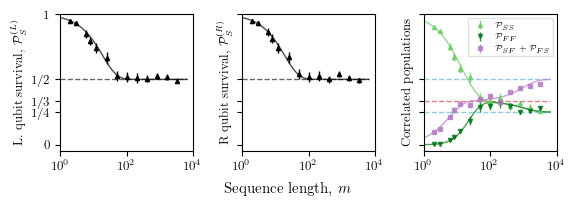

In [17]:
m = fh.SO3Model()

fig_width = gs.get_fig_width()
fig_height = gs.get_fig_width()/2.7

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(fig_width, fig_height))
fig, axs = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

# Plot two qubit decays
date = "2026-02-05"
rid = 93319 # 10 kHz detuning dataset
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
x_min = 1
x_max = max(df["Clifford Length"]) * 2
sim_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
plot_data_fit(axs[2], df, m, popt)

# Plot single qubit decays
x, P_L, P_L_err, P_R, P_R_err = m.get_single_qubit_pops(df)
e_cL, e_cR = m.get_single_qubit_errors(popt)
spam = popt[3]
P_L_fit = [m.single_qubit_model(i, e_cL, spam) for i in sim_line]
P_R_fit = [m.single_qubit_model(i, e_cR, spam) for i in sim_line]
for ax, P, P_err, P_fit, label in zip([axs[0], axs[1]], [P_L, P_R], [P_L_err, P_R_err], [P_L_fit, P_R_fit], ["L. qubit survival, $\\mathcal{P}_S^{(L)}$", "R qubit survival, $\\mathcal{P}_S^{(R)}$"]):
    ax.hlines(0.5, x_min, x_max, color="black", linestyle="--", alpha=0.6)
    ax.errorbar(df["Clifford Length"], P, yerr=P_err, fmt="^",color="black", alpha=1.0)
    ax.plot(sim_line, P_fit, color="black", alpha=gs.get_alpha(), linestyle="-")
    # turn off legend
    ax.legend().set_visible(False)
    ax.set_yticks([0, 1/4, 1/3, 1/2, 1.0])
    ax.set_yticklabels(["0", r"$1/4$",r"$1/3$", r"$1/2$", "1"])
    ax.set_ylabel(label)
    ax.set_xscale("log")


# Save the figure
# Optional: hide repeated tick labels
plt.setp(axs[1].get_yticklabels(), visible=False)
plt.setp(axs[2].get_yticklabels(), visible=False)
# remove grid lines
for ax in axs:
    ax.grid(False)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks([1, 100, 10000])


axs[2].set_ylabel("Correlated populations")
# raise supxlabel
fig.supxlabel("Sequence length, $m$", y=0.075)
plt.tight_layout()
# Print results
f_path = "..\\..\\pdf_figure\\ch4\\asymptotes_data.pdf"
plt.savefig(f_path, bbox_inches = "tight")

In [ ]:

# plot parities
# data from: 
cliffords = [50, 25, 12,  100, 200, 400, 800, 6, 3, 1600, 8, 2, 3200]
par_contrast = np.array([
    0.5738,
    0.5967,
    0.5525,
    0.5551,
    0.4517,
    0.3674,
    0.1941,
    0.3287,
    0.2634,
    0.1025,
    0.4192,
    0.1997,
    0.0213,
])*1/2
par_contrast_err = np.array([
    0.0343,
    0.0344,
    0.0273,
    0.0433,
    0.0373,
    0.0309,
    0.0118,
    0.0274,
    0.0577,
    0.0261,
    0.0268,
    0.0318,
    0.0304,
])*1/2

p_parity = ax4.errorbar(cliffords, par_contrast, yerr=par_contrast_err, color="black", fmt="^")

depol_popt = popt[1] + popt[2]  # Total depolarizing error from the previous fit

popt_infer = [popt[0], depol_popt]  # Initial guess for l and g from the previous fit
# combine index 1 and 2 of the covariance matrix to get the variance for the total depolarizing error
pcov_infer_diagonal = np.diag([pcov[0, 0], pcov[1, 1] + pcov[2, 2] + 2*pcov[1, 2]])  # Variance for the initial guess
# get covariance between index 0 and the total depolarizing error by summing the covariances of index 0 with index 1 and index 2
pcov_infer_offdiag = pcov[0, 1] + pcov[0, 2]  # Covariance between l and the total depolarizing error
pcov_infer = np.array([[pcov_infer_diagonal[0, 0], pcov_infer_offdiag], [pcov_infer_offdiag, pcov_infer_diagonal[1, 1]]])  # Covariance matrix for the initial guess
popt_par, pcov_par = curve_fit(m.parity_model, cliffords, par_contrast, p0=popt_infer)

fitted_parity_decay = m.parity_model(sim_line, *popt_infer)
fitted_parity_par = m.parity_model(sim_line, *popt_par)
# plot error bars for the fit by shading the area between the upper and lower bounds of the fit using MC method
# best-fit parameters and covariance from your fit
# draw correlated parameter samples
n_samples = 5000
param_samples = np.random.multivariate_normal(popt_infer, pcov_infer, size=n_samples)

# evaluate model for each sample
y_samples = np.array([m.parity_model(sim_line, *p) for p in param_samples])

# central 68% band, roughly 1-sigma
y_lo = np.percentile(y_samples, 16, axis=0)
y_hi = np.percentile(y_samples, 84, axis=0)

#plt.fill_between(sim_line, y_lo, y_hi, alpha=0.4, color="gray")

ax4.plot(sim_line, fitted_parity_par, color="black", alpha=gs.get_alpha(), linestyle="-")
ax4.hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
ax4.hlines(0, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
ax4.set_ylabel("Parity contrast, $C$")
ax4.set_ylim(-0.05, 1/3+0.05)
ax4.set_yticks([0, 1/3])
ax4.set_yticklabels(["0", r"$\frac{1}{3}$"])
ax4.set_xlabel("Sequence length, $m$")